# GAN
생성 모델은 최대한 진짜와 비슷한 데이터를 생성하려는 생성자와 진짜와 가찌를 구별하는 판별자가 각각 존재하여 서로 적대적으로 학습.

적대적 학습에서는 판별자를 먼저 학습시킨 후 생성자를 학습시키는 과정을 반복.

**판별자의 학습**
1. 실제 이미지를 입력해서 네트워크(신경망)가 해당 이미지를 진짜로 분류하도록 학습시킴.
2.  생성자가 생성한 모조 이미지를 입력해서 해당 이미지를 가짜로 분류하도록 학습시킴.

이 과정을 거쳐 판별자는 실제 이미지를 진짜로 분류하고, 모조 이미지를 가짜로 분류. 이와 같은 학습 과정을 반복하면 판별자와 생성자가 서로를 적대적인 경쟁자로 인식하여 모두 발전하게 됨.

## GAN 동작 원리
적대적 생성 신경망(GAN)은 생성자(Gcnerator)와 판별자(Discrirninator) 네트워크 두 개로 구성.
1. 판별자: 판별자D의 역할은주어진 입력 이미지가 진짜 이미지인지 가짜 이미지인지 구별하는 것. 즉 이미지 x가 입력으로 주어졌을 때 판별자D의 출력에 해당하는 D(x)가 진짜 이미지일 획률을 반환.
2. 생성자:  생성자 G의 역할은 판별자 D가 진짜인지 가짜인지 구별할 수 없을 만큼 진짜와 같은 모조 이미지를 노이즈 데이터를 사용하여 만들어 내는 것.

실제 데이터를 판단하려고 판별자 D를 학습시킬 때는 생성자 G를 고정시컨 채 실제 이미지는 높은 확률을 반환하는 방향으로 모조 이미지는 낮은 확률을 반환하는 방향으로 가중치를 업데이트.

In [1]:
# 라이브러리 호출
import imageio
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib
from torchvision.utils import save_image, make_grid
import torchvision.datasets as datasets
import torchvision.transforms as transforms
matplotlib.style.use('ggplot') #격자무늬 생성
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
# 변수 값 설정
batch_size=512
epochs=200
sample_size=64
nz=128
k=1

In [3]:
# MNIST룰 내려받은 후 정규화
transform =transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,)),
])
train_dataset=datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)
train_loader=DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 59.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.72MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.75MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [5]:
# 생성자 네트워크
class Generator(nn.Module):
  def __init__(self,nz):
    super(Generator,self).__init__()
    self.nz=nz
    self.main=nn.Sequential(
        nn.Linear(self.nz,256),
        nn.LeakyReLU(0.2),
        nn.Linear(256,512),
        nn.LeakyReLU(0.2),
        nn.Linear(512,1024),
        nn.LeakyReLU(0.2),
        nn.Linear(1024,784),
        nn.Tanh()
    )
  def forward(self,x):
    return self.main(x).view(-1,1,28,28)

In [6]:
# 판별자 네트워크 생성
class Discriminator(nn.Module):
  def __init__(self):
    super(Discriminator,self).__init__()
    self.n_input=784
    self.main=nn.Sequential(
        nn.Linear(self.n_input,1024),
        nn.LeakyReLU(0.2),
        nn.Dropout(0.3),
        nn.Linear(1024,512),
        nn.LeakyReLU(0.2),
        nn.Dropout(0.3),
        nn.Linear(512,256),
        nn.LeakyReLU(0.2),
        nn.Dropout(0.3),
        nn.Linear(256,1),
        nn.Sigmoid()
    )
  def forward(self,x):
    x=x.view(-1,784)
    return self.main(x)

In [7]:
# 생성자와 판별자 네트원크 초기화
generator=Generator(nz).to(device)
discriminator=Discriminator().to(device)
print(generator)
print(discriminator)

Generator(
  (main): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Linear(in_features=1024, out_features=784, bias=True)
    (7): Tanh()
  )
)
Discriminator(
  (main): Sequential(
    (0): Linear(in_features=784, out_features=1024, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=1024, out_features=512, bias=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=512, out_features=256, bias=True)
    (7): LeakyReLU(negative_slope=0.2)
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=256, out_features=1, bias=True)
    (10): Sigmoid()
  )
)


In [8]:
# 옵티마이저와 손실 함수 정의
optim_g=optim.Adam(generator.parameters(),lr=0.0002)
optim_d=optim.Adam(discriminator.parameters(),lr=0.0002)

criterion=nn.BCELoss()

losses_g=[]
losses_d=[]
images=[]

In [9]:
# 생성된 이미지 저장 함수 정의
def save_generator_image(image,path):
  save_image(image,path)

In [10]:
# 판별자 학습을 위한 함수
def train_discriminator(optimizer,data_real,data_fake):
  b_size=data_real.size(0)
  real_label=torch.ones(b_size,1).to(device)
  fake_label=torch.zeros(b_size,1).to(device)
  optimizer.zero_grad()
  output_real=discriminator(data_real)
  loss_real=criterion(output_real,real_label)
  output_fake=discriminator(data_fake)
  loss_fake=criterion(output_fake,fake_label)
  loss_real.backward()
  loss_fake.backward()
  optimizer.step()
  loss=loss_real+loss_fake
  return loss.item()

In [11]:
# 생성자 학습을 위한 함수
def train_generator(optimizer,data_fake):
  b_size=data_fake.size(0)
  real_label=torch.ones(b_size,1).to(device)
  optimizer.zero_grad()
  output=discriminator(data_fake)
  loss=criterion(output,real_label)
  loss.backward()
  optimizer.step()
  return loss.item()

In [12]:
# 모댈 학습
batch_size = 64
epochs = 30

generator.train()
discriminator.train()

for epoch in range(epochs):
  loss_g=0.0
  loss_d=0.0
  for idx,data in tqdm(enumerate(train_loader),total=int(len(train_dataset)/train_loader.batch_size)):
    image,_=data
    image=image.to(device)
    b_size=len(image)
    for step in range(k):
      data_fake=generator(torch.randn(b_size,nz).to(device)).detach()
      data_real=image
      loss_d+=train_discriminator(optim_d,data_real,data_fake)
    data_fake=generator(torch.randn(b_size,nz).to(device))
    loss_g+=train_generator(optim_g,data_fake)
  generated_img=generator(torch.randn(b_size,nz).to(device)).cpu().detach()
  generated_img=make_grid(generated_img)
  save_generator_image(generated_img,f"/content/data/gen_img{epoch}.png")
  epoch_loss_g=loss_g/idx
  epoch_loss_d=loss_d/len(train_loader)
  losses_g.append(epoch_loss_g)
  losses_d.append(epoch_loss_d)

  print(f'Epoch {epoch} of {epochs}')
  print(f'Generator loss: {epoch_loss_g:.8f}, Discriminator loss: {epoch_loss_d:.8f}')

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
118it [01:05,  1.79it/s]

Epoch 0 of 30
Generator loss: 1.53337877, Discriminator loss: 0.86191402



118it [01:01,  1.91it/s]

Epoch 1 of 30
Generator loss: 2.65010520, Discriminator loss: 1.19129718



118it [01:01,  1.92it/s]


...

Epoch 27 of 30
Generator loss: 2.80340867, Discriminator loss: 0.58949868



118it [01:03,  1.85it/s]

Epoch 28 of 30
Generator loss: 2.79527065, Discriminator loss: 0.48462331



118it [01:04,  1.83it/s]

Epoch 29 of 30
Generator loss: 2.91152408, Discriminator loss: 0.52066960


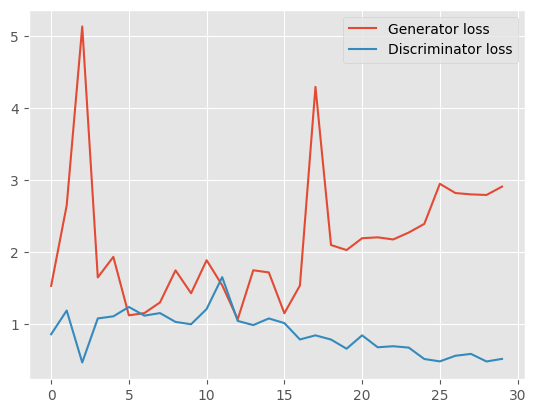

In [13]:
# 생성자와 판별자의 오차 확인
plt.figure()
losses_g = [f1.item() for f1 in losses_g]
plt.plot(losses_g,label='Generator loss')
losses_d = [f2.item() for f2 in losses_d]
plt.plot(losses_d,label='Discriminator loss')
plt.legend()
plt.show()

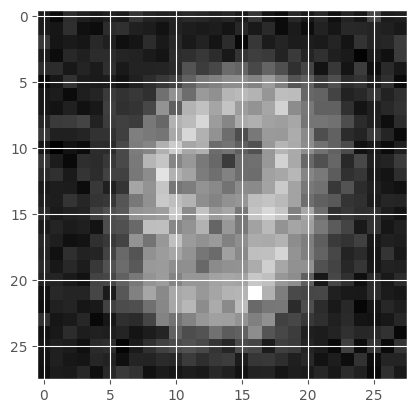

In [14]:
# 생성된 이미지 출력
fake_images=generator(torch.randn(b_size,nz).to(device))
import numpy as np
for i in range(10):
  fake_images_img=np.reshape(fake_images.data.cpu().numpy()[i],(28,28))
  plt.imshow(fake_images_img,cmap='gray')
  plt.savefig('/content/data/fake_images_img'+str(i)+'.png')
plt.show()